In [1]:
import pandas as pd

# Load the dataset from the specified path
df = pd.read_csv('/content/ds3.csv')

print("===== ORIGINAL DATA ====")
display(df.head())
print("\n===== DATA INFO ====")
df.info()

===== ORIGINAL DATA ====


,StudentID,Branch,EducationalLevel,Year,Campus,EventName,ParticipationType,CertificatesWon,EventCategory
0,S401,CSE,BTech,1,AUS,Tech Symposium,Participant,0,Technical
1,S402,AI&ML,BTech,2,ACET,AI Hackathon,Winner,1,Technical
2,S403,ECE,Diploma,3,AUS,Robotics Expo,Runner-up,1,Technical
3,S404,MECH,BTech,4,ACET,Auto Expo,Participant,0,Technical
4,S405,CIVIL,MTech,1,AUS,Bridge Design,Winner,1,Technical



===== DATA INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   StudentID          109 non-null    object
 1   Branch             109 non-null    object
 2   EducationalLevel   109 non-null    object
 3   Year               109 non-null    int64 
 4   Campus             109 non-null    object
 5   EventName          109 non-null    object
 6   ParticipationType  109 non-null    object
 7   CertificatesWon    109 non-null    int64 
 8   EventCategory      109 non-null    object
dtypes: int64(2), object(7)
memory usage: 7.8+ KB


In [2]:
# Display data information to check data types and non-null counts
print("===== DATA INFO ====")
df.info()

# Check for missing values
print("\n===== MISSING VALUES ====")
display(df.isnull().sum().sort_values(ascending=False))

===== DATA INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   StudentID          109 non-null    object
 1   Branch             109 non-null    object
 2   EducationalLevel   109 non-null    object
 3   Year               109 non-null    int64 
 4   Campus             109 non-null    object
 5   EventName          109 non-null    object
 6   ParticipationType  109 non-null    object
 7   CertificatesWon    109 non-null    int64 
 8   EventCategory      109 non-null    object
dtypes: int64(2), object(7)
memory usage: 7.8+ KB

===== MISSING VALUES ====


,0
StudentID,0
Branch,0
EducationalLevel,0
Year,0
Campus,0
EventName,0
ParticipationType,0
CertificatesWon,0
EventCategory,0


### Data Preprocessing

Data preprocessing involves transforming raw data into an understandable format. This includes cleaning the data, handling missing values, converting data types, and often feature engineering. It ensures the data is suitable for machine learning algorithms.

First, we'll address any missing values. Common strategies include:
- **Dropping rows/columns**: If a significant portion of a row or column is missing, or if the missingness is random and limited.
- **Imputation**: Filling missing values with a placeholder, such as the mean, median, or mode for numerical data, or a common category for categorical data. The choice of imputation strategy depends on the nature of the data and the extent of missingness.

In [3]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Categorical columns: {list(categorical_cols)}")

# --- Handling Missing Values ---

# For numerical columns, fill missing values with the mean
# Note: This is a simple strategy. A more robust approach might use median or a more sophisticated imputation method.
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# For categorical columns, fill missing values with the mode
# Note: This is a simple strategy. Consider adding an 'Unknown' category or using more advanced imputation.
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("\n===== MISSING VALUES AFTER HANDLING ====")
display(df.isnull().sum().sort_values(ascending=False))

Numerical columns: ['Year', 'CertificatesWon']
Categorical columns: ['StudentID', 'Branch', 'EducationalLevel', 'Campus', 'EventName', 'ParticipationType', 'EventCategory']

===== MISSING VALUES AFTER HANDLING ====


,0
StudentID,0
Branch,0
EducationalLevel,0
Year,0
Campus,0
EventName,0
ParticipationType,0
CertificatesWon,0
EventCategory,0


Now that we've handled missing values, let's move on to the next topic: **Association Rules** and the **Apriori Algorithm**. This algorithm is used to find frequent itemsets and derive association rules from transactional datasets, often used in market basket analysis.

### Association Rules and Apriori Algorithm

**Association Rule Mining** is a technique used to find interesting relationships, or associations, among a set of items in a dataset. It is widely used in market basket analysis, where it helps in identifying products that are frequently bought together.

Key concepts:
-   **Itemset**: A collection of one or more items (e.g., `{Milk, Bread}`).
-   **Support**: The popularity of an itemset. It's the proportion of transactions that contain the itemset. `Support(X) = (Number of transactions containing X) / (Total number of transactions)`.
-   **Confidence**: How likely item Y is purchased when item X is purchased. `Confidence(X -> Y) = Support(X and Y) / Support(X)`.
-   **Lift**: How much more likely item Y is purchased when item X is purchased, while controlling for the popularity of Y. `Lift(X -> Y) = Confidence(X -> Y) / Support(Y)`.

The **Apriori Algorithm** is a classic algorithm for mining frequent itemsets and deriving association rules. It works by iteratively identifying frequent individual items in the database and then extending them to larger and larger itemsets as long as those itemsets appear sufficiently often in the database.

In [4]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# For Apriori, we need data in a transactional format (list of lists)
# Each transaction should represent a unique combination of StudentID and the events they participated in or categories.
# Let's consider each student's unique set of EventCategories as a transaction.

transactions = df.groupby('StudentID')['EventCategory'].apply(list).tolist()

# Use TransactionEncoder to convert the list of lists into a one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

print("Transactional Data Sample (One-Hot Encoded):")
display(df_transactions.head())

# Apply the Apriori algorithm to find frequent itemsets
# min_support specifies the minimum support threshold (e.g., 0.1 for 10%)
frequent_itemsets = apriori(df_transactions, min_support=0.1, use_colnames=True)

print("\nFrequent Itemsets (min_support=0.1):")
display(frequent_itemsets.sort_values(by='support', ascending=False))

# Generate association rules from the frequent itemsets
# min_confidence specifies the minimum confidence threshold (e.g., 0.7 for 70%)
# The 'metric' and 'min_threshold' parameters are flexible and can be adjusted
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print("\nAssociation Rules (min_confidence=0.7):")
display(rules.sort_values(by='lift', ascending=False))

Transactional Data Sample (One-Hot Encoded):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Cultural,Sports,Technical
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True



Frequent Itemsets (min_support=0.1):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
2,0.55,(Technical)
0,0.26,(Cultural)
1,0.19,(Sports)



Association Rules (min_confidence=0.7):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Decision Trees

A **Decision Tree** is a supervised learning algorithm used for both classification and regression tasks. It builds a model in the form of a tree structure, where each internal node represents a 'test' on an attribute (e.g., is the `Year` greater than 2?), each branch represents the outcome of the test, and each leaf node represents a class label (in classification) or a predicted value (in regression).

Key advantages of Decision Trees include:
-   **Interpretability**: They are easy to understand and visualize.
-   **Versatility**: Can handle both numerical and categorical data.
-   **No Scaling Needed**: They do not require feature scaling.

However, they can be prone to overfitting, which can be mitigated using techniques like pruning or ensemble methods (e.g., Random Forests, Gradient Boosting).

To build a decision tree, we first need to prepare our data. This typically involves:
1.  **Feature Engineering**: Creating new features if necessary.
2.  **Encoding Categorical Variables**: Converting categorical columns into numerical representations that the algorithm can process.
3.  **Splitting Data**: Dividing the dataset into training and testing sets to evaluate the model's performance.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# For Decision Trees, we need to encode categorical features into numerical ones.
# Let's select relevant features for predicting, for example, `ParticipationType` or `CertificatesWon`.

# Identify categorical columns that need encoding (excluding StudentID if it's just an identifier)
categorical_features_for_dt = [col for col in df.select_dtypes(include=['object', 'category']).columns if col != 'StudentID']

# Create a copy of the dataframe to avoid modifying the original during encoding for this specific task
df_encoded = df.copy()

# Apply Label Encoding to categorical features
for col in categorical_features_for_dt:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Column '{col}' encoded with {len(le.classes_)} classes.")

print("\nDataFrame after Label Encoding:")
display(df_encoded.head())

# Define features (X) and target (y)
# Let's try to predict 'ParticipationType' based on other features
features = df_encoded.drop(columns=['StudentID', 'ParticipationType'])
target = df_encoded['ParticipationType']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

print("\nData preparation for Decision Tree complete. Next, we will build and train the Decision Tree model.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Column 'Branch' encoded with 5 classes.
Column 'EducationalLevel' encoded with 7 classes.
Column 'Campus' encoded with 2 classes.
Column 'EventName' encoded with 99 classes.
Column 'ParticipationType' encoded with 3 classes.
Column 'EventCategory' encoded with 3 classes.

DataFrame after Label Encoding:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,StudentID,Branch,EducationalLevel,Year,Campus,EventName,ParticipationType,CertificatesWon,EventCategory
0,S401,2,2,1,1,94,0,0,2
1,S402,0,2,2,0,2,2,1,2
2,S403,3,3,3,1,83,1,1,2
3,S404,4,2,4,0,15,0,0,2
4,S405,1,6,1,1,20,2,1,2



Training features shape: (76, 7)
Testing features shape: (33, 7)
Training target shape: (76,)
Testing target shape: (33,)

Data preparation for Decision Tree complete. Next, we will build and train the Decision Tree model.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Decision Tree Classifier trained successfully!

Accuracy: 0.91

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       1.00      0.50      0.67         4
           2       0.83      1.00      0.91        15

    accuracy                           0.91        33
   macro avg       0.94      0.81      0.85        33
weighted avg       0.92      0.91      0.90        33


Confusion Matrix:
 [[13  0  1]
 [ 0  2  2]
 [ 0  0 15]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

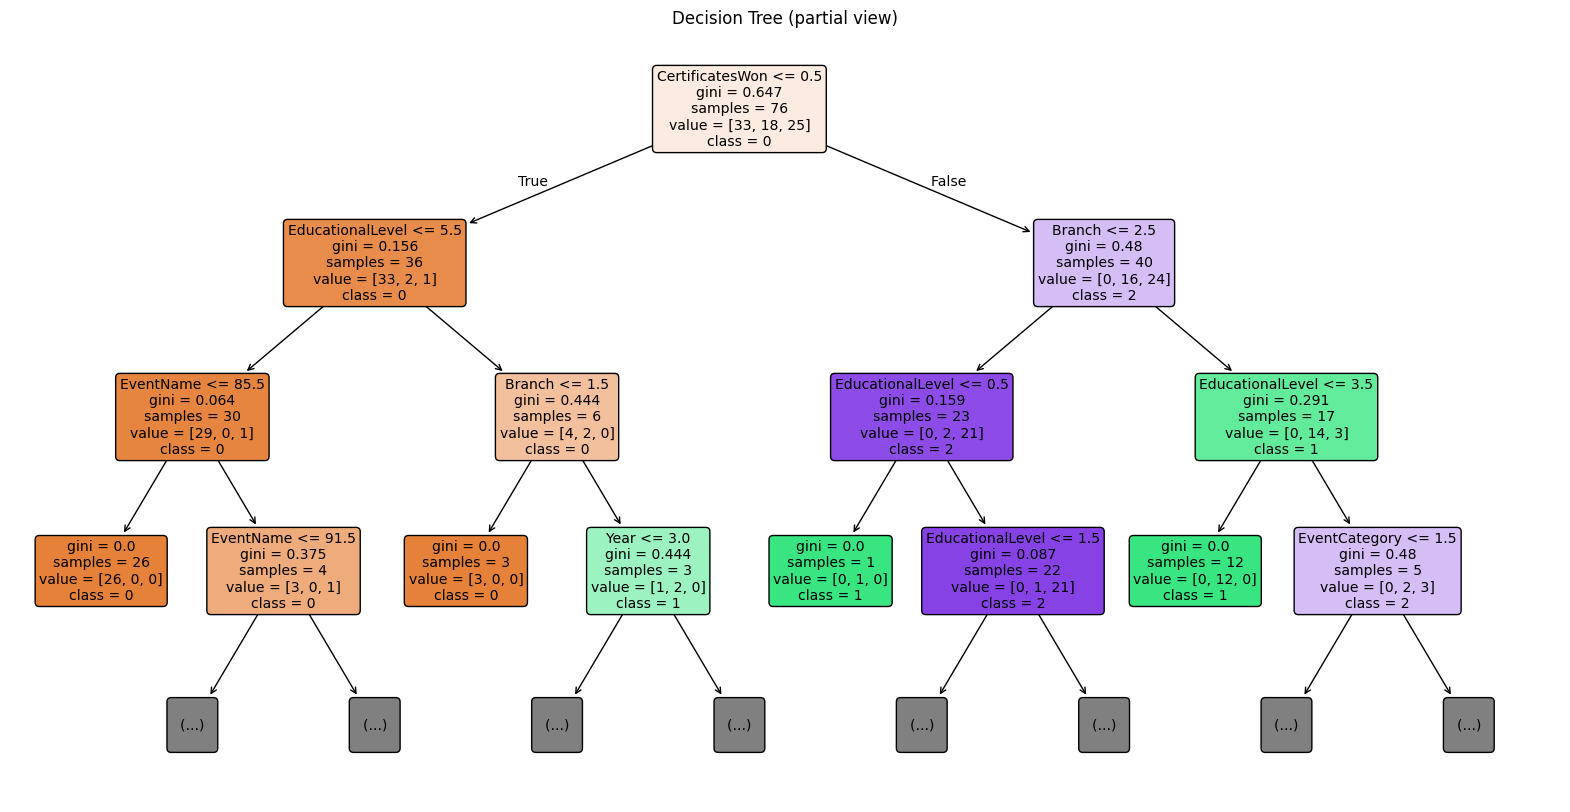

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Initialize the Decision Tree Classifier
# You can tune hyperparameters like max_depth, min_samples_leaf, etc., to prevent overfitting.
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

# Visualize the Decision Tree (optional, for smaller trees)
# This can be very large for complex trees, so we'll set a max_depth for visualization
plt.figure(figsize=(20, 10))
plot_tree(dtc, feature_names=features.columns, class_names=[str(i) for i in sorted(y_train.unique())], filled=True, rounded=True, max_depth=3)
plt.title("Decision Tree (partial view)")
plt.show()

### Clustering

**Clustering** is an unsupervised machine learning technique used to group a set of objects in such a way that objects in the same group (called a cluster) are more similar to each other than to those in other groups. Unlike supervised learning, clustering does not require labeled data and is often used for exploratory data analysis, anomaly detection, and segmentation.

Key concepts:
-   **Unsupervised Learning**: No target variable is needed; the algorithm discovers patterns on its own.
-   **Similarity Measure**: Clusters are formed based on how similar data points are to each other (e.g., Euclidean distance, cosine similarity).
-   **Centroid**: In some algorithms (like K-Means), clusters are represented by a central point.

One of the most popular clustering algorithms is **K-Means**. It aims to partition `n` observations into `k` clusters in which each observation belongs to the cluster with the nearest mean (centroid), serving as a prototype of the cluster. This results in a partitioning of the data space into Voronoi cells.

To apply clustering, we typically need to:
1.  **Feature Selection**: Choose relevant features for clustering.
2.  **Feature Scaling**: Scale numerical features to ensure that no single feature dominates the distance calculations.
3.  **Determine Optimal K**: For K-Means, finding the appropriate number of clusters (`k`) is crucial, often done using methods like the Elbow method or Silhouette score.
4.  **Apply Clustering Algorithm**: Run the chosen algorithm.
5.  **Interpret Results**: Analyze the characteristics of each cluster.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# For clustering, we will use the df_encoded dataframe.
# We should scale numerical features to ensure they contribute equally to distance calculations.

# Select features for clustering. Exclude 'StudentID' and 'ParticipationType' as it was our target for DT.
# Let's consider 'Year', 'CertificatesWon', and other encoded categorical features.
clustering_features = df_encoded.drop(columns=['StudentID', 'ParticipationType'])

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

# Determine the optimal number of clusters (K) using the Elbow Method
# We'll try a range of K values and plot the inertia (sum of squared distances of samples to their closest cluster center)
wss = [] # Within-cluster sum of squares
for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("\nThe Elbow method plot helps us visually determine the optimal number of clusters (K). We look for the 'elbow point' where the decrease in WSS starts to slow down significantly.")

# Based on the Elbow method (visual inspection will be done by the user), let's assume K=3 for demonstration.
# You might adjust this based on the plot.
k = 3 # Example K
kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
df_encoded['Cluster'] = kmeans_model.fit_predict(scaled_features)

print(f"\nK-Means Clustering performed with K = {k} clusters.")
print("\nCluster distribution:")
display(df_encoded['Cluster'].value_counts().sort_index())

print("\nMean values of features per cluster (unscaled for interpretability):")
display(df_encoded.groupby('Cluster').mean(numeric_only=True))

### Data Visualization

**Data Visualization** is the graphical representation of information and data. By using visual elements like charts, graphs, and maps, data visualization tools provide an accessible way to see and understand trends, outliers, and patterns in data. In the world of big data, data visualization tools and technologies are essential for analyzing massive amounts of information and making data-driven decisions.

Key aspects of data visualization:
-   **Exploration**: Helps in understanding the data's underlying structure.
-   **Communication**: Effectively conveys findings to others.
-   **Identification**: Reveals patterns, trends, and outliers that might not be obvious in raw data.

Let's create a few visualizations to understand our dataset better, especially in light of the clustering we just performed.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

print("Visualizing data...")

# 1. Distribution of Event Categories
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='EventCategory', palette='viridis')
plt.title('Distribution of Event Categories')
plt.xlabel('Event Category')
plt.ylabel('Number of Participants')
plt.show()

# 2. Certificates Won by Educational Level
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='EducationalLevel', y='CertificatesWon', estimator=sum, palette='plasma')
plt.title('Total Certificates Won by Educational Level')
plt.xlabel('Educational Level')
plt.ylabel('Total Certificates Won')
plt.xticks(rotation=45)
plt.show()

# 3. Pairplot of numerical features colored by Cluster (if clusters were identified)
# We'll use the original numerical features and 'Cluster' column from df_encoded
if 'Cluster' in df_encoded.columns:
    print("\nVisualizing clusters with pairplot...")
    # Merge cluster back to original df for easier plotting with original values or relevant encoded values
    df_plot = df_encoded.copy()

    # For the pairplot, let's select a few key features and the cluster column
    # Original features for better interpretability in the plot axes
    df_plot['Year_orig'] = df['Year']
    df_plot['CertificatesWon_orig'] = df['CertificatesWon']
    df_plot['EducationalLevel_orig'] = df['EducationalLevel'] # Add original categorical for legend

    # Map encoded 'EducationalLevel' back to original string for better legend
    # This requires recreating the LabelEncoder for EducationalLevel if we want readable labels in the plot
    le_edu = LabelEncoder()
    le_edu.fit(df['EducationalLevel'])
    df_plot['EducationalLevel_decoded'] = le_edu.inverse_transform(df_encoded['EducationalLevel'])

    # Select features for the pairplot
    pairplot_cols = ['Year_orig', 'CertificatesWon_orig', 'Cluster']
    sns.pairplot(df_plot, vars=pairplot_cols[:-1], hue='Cluster', palette='deep')
    plt.suptitle('Pairplot of Numerical Features by Cluster', y=1.02)
    plt.show()

    print("\nMean values of original features per cluster for better interpretation:")
    display(df.groupby(df_encoded['Cluster']).agg({
        'Year': 'mean',
        'CertificatesWon': 'mean',
        'Branch': lambda x: x.mode()[0] if not x.mode().empty else None,
        'EducationalLevel': lambda x: x.mode()[0] if not x.mode().empty else None,
        'Campus': lambda x: x.mode()[0] if not x.mode().empty else None,
        'EventCategory': lambda x: x.mode()[0] if not x.mode().empty else None
    }))
else:
    print("Clustering not performed or 'Cluster' column not found in df_encoded. Skipping cluster visualization.")

print("\nAll requested topics covered!")